importing lib

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn

In [7]:
data = pd.read_csv("LTOTALNSA.csv",index_col="observation_date")

<Axes: >

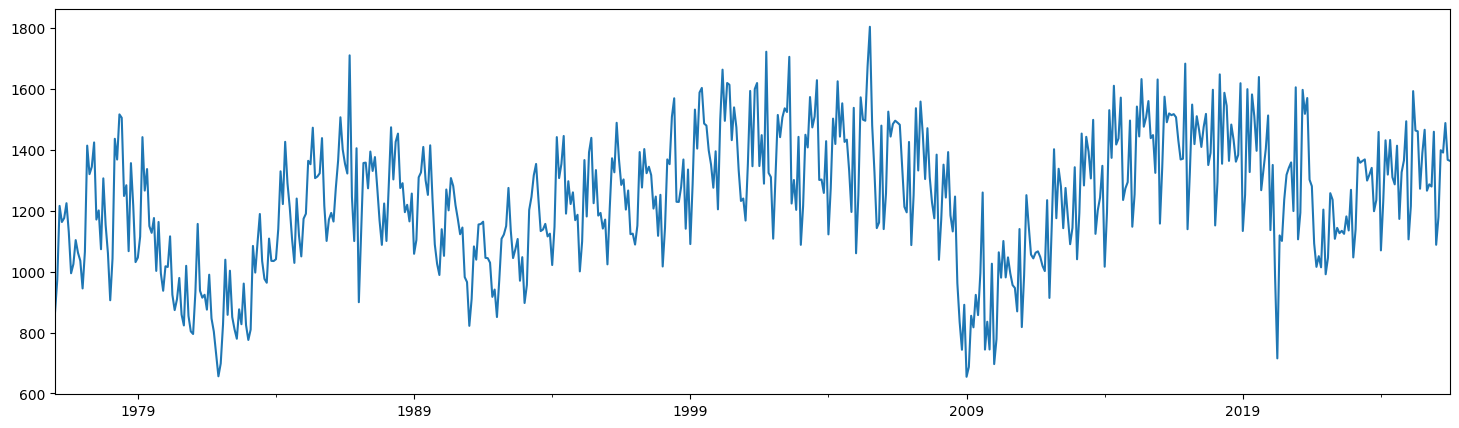

In [49]:
plt.figure(figsize=(18,5))
data["LTOTALNSA"].plot()

In [29]:
range = pd.date_range("1976-01-01","2026-07-01",freq="MS")

In [32]:
data.describe()

,LTOTALNSA
count,607.000000
mean,1237.559270
std,213.603251
min,654.893000
25%,1100.677500
50%,1246.700000
75%,1393.587000
max,1804.325000


In [34]:
data.info()

<class 'pandas.DataFrame'>
Index: 607 entries, 1976-01-01 to 2026-07-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LTOTALNSA  607 non-null    float64
dtypes: float64(1)
memory usage: 25.6+ KB


In [39]:
data.index = range

In [47]:
monthly_performance = data.resample("MS").sum()

In [46]:
quaterly_performance = data.resample("QS").sum()

<BarContainer object of 203 artists>

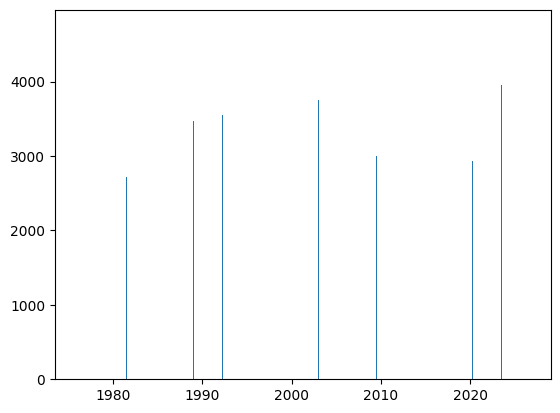

In [54]:
plt.bar(x=quaterly_performance.index,height=quaterly_performance["LTOTALNSA"])

In [55]:
shifted_data = data.shift(1)

In [56]:
differnce = data-shifted_data

<Figure size 2000x500 with 0 Axes>

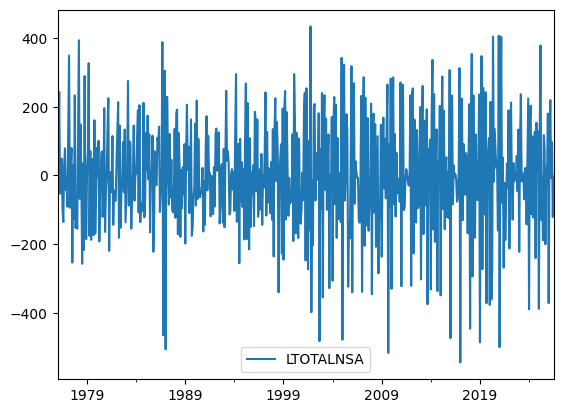

In [ ]:
a = plt.figure(figsize=(20,5))
differnce.plot()
plt.show()

In [69]:
data

,LTOTALNSA
1976-01-01,864.600
1976-02-01,973.300
1976-03-01,1216.100
1976-04-01,1163.200
1976-05-01,1176.100
...,...
2026-03-01,1398.940
2026-04-01,1391.179
2026-05-01,1488.150
2026-06-01,1367.435


In [85]:
# Pass 3 as an integer, not a string
monthly_performance["rolling_mean_quarterly"] = (
    monthly_performance["LTOTALNSA"].rolling(window=3).mean()
)


In [86]:
monthly_performance

,LTOTALNSA,rolling_mean_quarterly
1976-01-01,864.600,NaN
1976-02-01,973.300,NaN
1976-03-01,1216.100,1018.000000
1976-04-01,1163.200,1117.533333
1976-05-01,1176.100,1185.133333
...,...,...
2026-03-01,1398.940,1222.338000
2026-04-01,1391.179,1323.269000
2026-05-01,1488.150,1426.089667
2026-06-01,1367.435,1415.588000


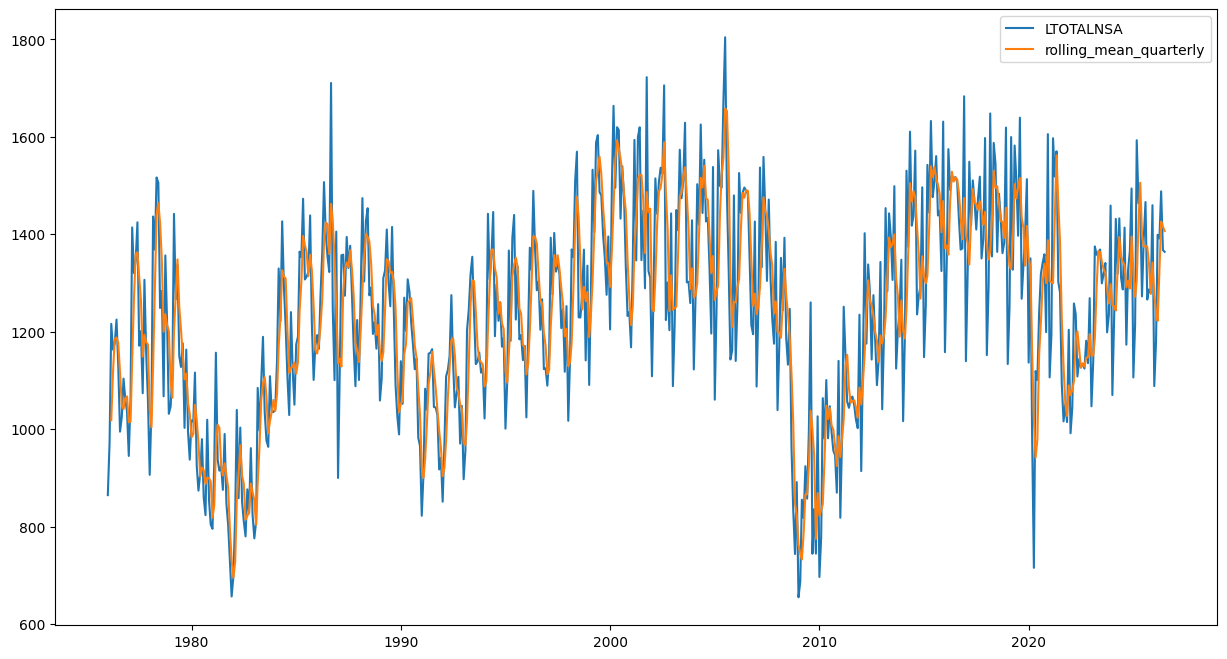

In [91]:
plt.figure(figsize=(15,8))
plt.plot(monthly_performance["LTOTALNSA"])
plt.plot(monthly_performance["rolling_mean_quarterly"])
plt.legend(["LTOTALNSA","rolling_mean_quarterly"])
plt.show()